In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.init as init
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import datetime

In [13]:
# Pat, need to use GPU to load (bc I used it to train, so the model is an object on a CUDA device),
# On colab: go to runtime, change runtime type, and select any of the GPUs available (A100, V100, T4)
# if on VSCode, you will need to download torch version with access to GPU, run command: pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
is_cuda = torch.cuda.is_available()
if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("stop what are you doing regard, use the GPU")

GPU is available


In [17]:
def load_checkpoint(model, optimizer, filename):
    checkpoint = torch.load(filename)
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']

    return model, optimizer, epoch, loss

def input_data(original_tensor, ws=65):
    output_tensor = torch.empty(0, device=original_tensor.device)
    for i in range(len(original_tensor) - (ws - 1)):
        temp_tensor = original_tensor[i:i + ws].unsqueeze(0)
        output_tensor = torch.cat((output_tensor, temp_tensor), dim=0)
    return output_tensor

def central_diff(x, dt):
    dx_dt = torch.zeros_like(x, dtype=x.dtype, device=x.device)
    dx_dt[:,1:-1,:] = (x[:,2:,:] - x[:,:-2,:]) / (dt[:,:-2,:] + dt[:,1:-1,:])
    dx_dt[:,0,:] = (x[:,1,:] - x[:,0,:]) / dt[:,0,:]
    dx_dt[:,-1,:] = (x[:,-1,:] - x[:,-2,:]) / dt[:,-2,:]
    return dx_dt

In [18]:
class I2S(nn.Module):

    def __init__(self, input_size=6, hidden_size=37, num_layers=3, out_size=9):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dtype=torch.float32)
        self.linear = nn.Linear(hidden_size,out_size)
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                init.xavier_uniform_(param.data)

    def forward(self,seq):
        h_0 = torch.zeros(self.num_layers, seq.size(0), self.hidden_size, dtype=torch.float32).requires_grad_().to(device)
        c_0 = torch.zeros(self.num_layers, seq.size(0), self.hidden_size, dtype=torch.float32).requires_grad_().to(device)
        lstm_out, (hn, cn) = self.lstm(seq, (h_0, c_0))
        pred = self.linear(lstm_out)
        return pred

class S2U(nn.Module):

    def __init__(self, input_size=9, hidden_size=37, num_layers=3, out_size=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size,hidden_size,num_layers,batch_first=True,dtype=torch.float32)
        self.linear = nn.Linear(hidden_size,out_size)
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                init.xavier_uniform_(param.data)

    def forward(self,seq):
        h_0 = torch.zeros(self.num_layers, seq.size(0), self.hidden_size, dtype=torch.float32).requires_grad_().to(device)
        c_0 = torch.zeros(self.num_layers, seq.size(0), self.hidden_size, dtype=torch.float32).requires_grad_().to(device)
        lstm_out, (hn, cn) = self.lstm(seq, (h_0, c_0))
        pred = self.linear(lstm_out)
        return pred


class U2F(nn.Module):

    def __init__(self, input_size=2, hidden_size=50, num_layers=5, out_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size,hidden_size,num_layers,batch_first=True,dropout=0.05,dtype=torch.float32)
        self.dropout = nn.Dropout(p=0.1)
        self.linear = nn.Linear(hidden_size,out_size)
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                init.xavier_uniform_(param.data)

    def forward(self,seq):

        h_0 = torch.zeros(self.num_layers, seq.size(0), self.hidden_size, dtype=torch.float32).requires_grad_().to(device)
        c_0 = torch.zeros(self.num_layers, seq.size(0), self.hidden_size, dtype=torch.float32).requires_grad_().to(device)
        lstm_out, (hn, cn) = self.lstm(seq, (h_0, c_0))
        lstm_out = self.dropout(lstm_out)
        pred = self.linear(lstm_out)
        return pred

In [20]:
hyperparameters =  {'i2s_hidden_size': 70,
                    's2u_hidden_size': 71,
                    'u2f_hidden_size': 14,
                    'i2s_num_layers': 4,
                    's2u_num_layers': 4,
                    'u2f_num_layers': 5,
                    'learning_rate_i2s': 0.007261213039014494,
                    'learning_rate_s2u': 0.004726479969598944,
                    'learning_rate_u2f': 0.005623188164342498,
                    'phys_weight': 410.29148077706907,
                    'data_weight': 0.0706670143796514,
                    'num_epochs': 115}
mse_loss = nn.MSELoss()
phys_weight = hyperparameters['phys_weight']
data_weight = hyperparameters['data_weight']

In [30]:
i2s_init = I2S(hidden_size=hyperparameters['i2s_hidden_size'], num_layers=hyperparameters['i2s_num_layers'])
optim_1_init = torch.optim.Adam(i2s_init.parameters(), lr=hyperparameters['learning_rate_i2s'])
i2s, optim_1, epoch_i2s, loss_i2s = load_checkpoint(i2s_init, optim_1_init, '/content/i2s_checkpoint.pth')

s2u_init = S2U(hidden_size=hyperparameters['s2u_hidden_size'], num_layers=hyperparameters['s2u_num_layers'])
optim_2_init = torch.optim.Adam(s2u_init.parameters(), lr=hyperparameters['learning_rate_s2u'])
s2u, optim_2, epoch_s2u, loss_s2u = load_checkpoint(s2u_init, optim_2_init, '/content/s2u_checkpoint.pth')

u2f_init = U2F(hidden_size=hyperparameters['u2f_hidden_size'], num_layers=hyperparameters['u2f_num_layers'])
optim_3_init = torch.optim.Adam(u2f_init.parameters(), lr=hyperparameters['learning_rate_u2f'])
u2f, optim_3, epoch_u2f, loss_u2f = load_checkpoint(u2f_init, optim_3_init, '/content/u2f_checkpoint.pth')

i2s.to(device)
s2u.to(device)
u2f.to(device)

In [36]:
test_data = pd.read_csv('data_voltagevarying.csv')
mask = test_data['Time'].diff().shift(-1) < 0.01
test_data = test_data[~mask]
t, x, dxdt, volt, f = test_data['Time'], test_data['Position'], test_data['Velocity'], test_data['Voltage'], test_data['Force']
t_np, x_np, dxdt_np, volt_np, f_np = t.to_numpy(), x.to_numpy(), dxdt.to_numpy(), volt.to_numpy(), f.to_numpy()
window_size = 30
poly_order = 8
dxdt_np = savgol_filter(dxdt_np, window_length=window_size, polyorder=poly_order)

#Evolutionary variables
dt_np = t_np[1:] - t_np[:-1]
dx_np = x_np[1:] - x_np[:-1]
dv_np = dxdt_np[1:] - dxdt_np[:-1]

#Ensure uniform length
min_length = min(len(t_np), len(x_np), len(dxdt_np), len(volt_np), len(f_np), len(dt_np), len(dx_np), len(dv_np))
t = t_np[:min_length]
dt = dt_np[:min_length]
x = x_np[:min_length]
v = dxdt_np[:min_length]
dx = dx_np[:min_length]
dv = dv_np[:min_length]
volt = volt_np[:min_length]
f = f_np[:min_length]

#Tensors
t_t = torch.tensor(t, dtype=torch.float32, device=device)
dt_t = torch.tensor(dt, dtype=torch.float32, device=device)
volt_t = torch.tensor(volt, dtype=torch.float32, device=device)

#Standardization & tensors
x_t = torch.tensor(x, dtype=torch.float32, device=device)
displace = x_t.cpu().clone()
x_t = (x_t-x_t.mean(dim=0))/x_t.std(dim=0)
v_t = torch.tensor(v, dtype=torch.float32, device=device)
velocity = v_t.cpu().clone()
v_t = (v_t-v_t.mean(dim=0))/v_t.std(dim=0)
dx_t = torch.tensor(dx, dtype=torch.float32, device=device)
dx_t = (dx_t-dx_t.mean(dim=0))/dx_t.std(dim=0)
dv_t = torch.tensor(dv, dtype=torch.float32, device=device)
dv_t = (dv_t-dv_t.mean(dim=0))/dv_t.std(dim=0)
f_t = torch.tensor(f, dtype=torch.float32, device=device)
f_t = (f_t-f_t.mean(dim=0))/f_t.std(dim=0)


#Sliding window sequence
t_data = input_data(t_t.unsqueeze(1))
dt_data = input_data(dt_t.unsqueeze(1))
x_data = input_data(x_t.unsqueeze(1))
v_data = input_data(v_t.unsqueeze(1))
dx_data = input_data(dx_t.unsqueeze(1))
dv_data = input_data(dv_t.unsqueeze(1))
volt_data = input_data(volt_t.unsqueeze(1))
f_data = input_data(f_t.unsqueeze(1))

concat = torch.cat((dt_data, x_data, v_data, dx_data, dv_data, volt_data, t_data, f_data), dim=2).to(torch.float32)
input = concat.clone()
print(f"Input shape: {input.shape}. Device: {input.device}")

Input shape: torch.Size([42044, 65, 8]). Device: cuda:0


In [40]:
%%time

torch.manual_seed(42)
loader_batch_size = 128
test_loader = data.DataLoader(input, shuffle=True, batch_size=loader_batch_size)
test_t_list = []
test_f_list = []
with torch.no_grad():
    list(map(lambda net: net.eval(), [i2s, s2u, u2f]))
    for val_item in test_loader:

        val_inp = val_item[:,:,:-2]
        val_t_label = val_item[:,:,-2]
        val_f_label = val_item[:,:,-1]

        test_t_list.append(val_t_label)

        val_dt,val_x,val_v,val_dx,val_dv,val_volt = torch.chunk(val_inp, chunks=6, dim=2)
        val_state_space = i2s(val_inp)
        val_I1, val_I2, val_I3, val_I4, val_I5, val_I6, val_I7, val_I8, val_I9 = torch.chunk(val_state_space, chunks=9, dim=2)
        val_pred_yz = s2u(val_state_space)
        val_y, val_z  = torch.chunk(val_pred_yz, chunks=2, dim=2)
        val_dydt = central_diff(val_y,val_dt)
        u2f_in = torch.cat((val_x,val_dydt),dim=2)
        val_pred_f = u2f(u2f_in)

        test_f_list.append(val_pred_f)



CPU times: user 1.36 s, sys: 10.6 ms, total: 1.37 s
Wall time: 1.56 s


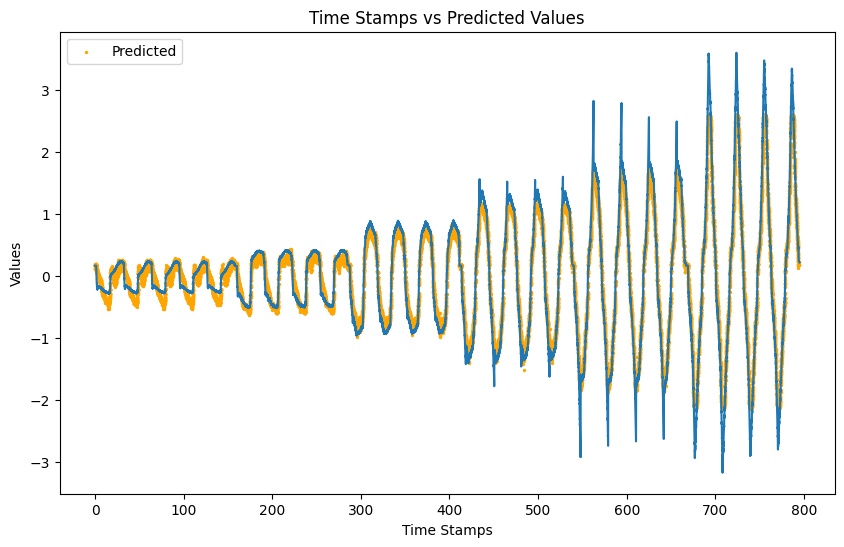

In [43]:
flat_test_t_list = np.concatenate([item[:, 0].cpu().numpy() for item in test_t_list], axis=0)
flat_test_f_list = np.concatenate([item[:, 0, 0].cpu().numpy() for item in test_f_list], axis=0)

# Plot only the overlapping portion
min_length = min(len(flat_test_t_list), len(flat_test_f_list))
displace = displace[:min_length]
time_steps = np.arange(min_length)

plt.figure(figsize=(10, 6))
plt.scatter(flat_test_t_list[:min_length], flat_test_f_list[:min_length], label='Predicted', marker='o', color = 'orange', s=2)
plt.plot(t_t.cpu(),f_t.cpu())

plt.xlabel('Time Stamps')
plt.ylabel('Values')
plt.title('Time Stamps vs Predicted Values')
plt.legend()
plt.show()